# Classification des œuvres de Zola et d'autres naturalistes

## Expérience sans retrait des noms propres (nom de famille et prenom)

## 1. Importation des bibliothèques

In [1]:
# Fichiers et données
import os
import glob
import json
import random
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import balanced_accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedGroupKFold, cross_validate
from sklearn.metrics import (accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay)
print("Toutes les bibliothèques sont chargées.")


Toutes les bibliothèques sont chargées.


## 2. Normalisation des apostrophes

Les textes ayant été préalablement nettoyés, certaines apostrophes ont
disparu. Cette étape restaure les contractions les plus fréquentes à partir
d'un dictionnaire de correspondances.

N.b: Les formes `dune` et `lune` sont respectivement interprétées comme `d'une`
et `l'une`. Ce choix repose sur l'hypothèse que les occurrences des noms
communs *dune* et *lune* sont minoritaires dans le corpus étudié.

In [2]:
REMPLACEMENTS_APOSTROPHES = {
    # ========================================================
    # Locutions longues : à traiter avant les formes courtes
    # ========================================================
    "lorsquil": "lorsqu'il",
    "lorsquils": "lorsqu'ils",
    "lorsquon": "lorsqu'on",
    "lorsquune": "lorsqu'une",
    "lorsquun": "lorsqu'un",
    "lorsquelle": "lorsqu'elle",
    "lorsquelles": "lorsqu'elles",

    "puisquil": "puisqu'il",
    "puisquils": "puisqu'ils",
    "puisquon": "puisqu'on",
    "puisquune": "puisqu'une",
    "puisquun": "puisqu'un",
    "puisquelle": "puisqu'elle",
    "puisquelles": "puisqu'elles",

    "quoiquil": "quoiqu'il",
    "quoiquils": "quoiqu'ils",
    "quoiquon": "quoiqu'on",
    "quoiquelle": "quoiqu'elle",

    "jusquil": "jusqu'il",
    "jusquils": "jusqu'ils",
    "jusquon": "jusqu'on",
    "jusquune": "jusqu'une",
    "jusquun": "jusqu'un",
    "jusquelle": "jusqu'elle",
    "jusquelles": "jusqu'elles",
    "jusquà": "jusqu'à",
    "jusquau": "jusqu'au",
    "jusquaux": "jusqu'aux",

    # ========================================================
    # Contractions avec c'
    # ========================================================
    "cest": "c'est",
    "cétait": "c'était",
    "cétaient": "c'étaient",
    "cétant": "c'étant",
    "cen": "c'en",

    # ========================================================
    # Contractions avec s'
    # ========================================================
    "sest": "s'est",
    "sétait": "s'était",
    "sétaient": "s'étaient",
    "sétant": "s'étant",
    "sen": "s'en",
    "sy": "s'y",
    "sil": "s'il",
    "sils": "s'ils",

    # ========================================================
    # Contractions avec n'
    # ========================================================
    "nest": "n'est",
    "nétait": "n'était",
    "nétaient": "n'étaient",
    "navait": "n'avait",
    "navaient": "n'avaient",
    "naurait": "n'aurait",
    "nauraient": "n'auraient",
    "naura": "n'aura",
    "nauront": "n'auront",
    "na": "n'a",
    "nont": "n'ont",
    "nen": "n'en",
    "ny": "n'y",
    "navoir": "n'avoir",
    "nêtre": "n'être",
    "nai": "n'ai",
    "navez": "n'avez",

    # ========================================================
    # Contractions avec j'
    # ========================================================
    "jai": "j'ai",
    "javais": "j'avais",
    "jétais": "j'étais",
    "jaurais": "j'aurais",
    "jaurai": "j'aurai",
    "jaime": "j'aime",
    "jallais": "j'allais",
    "jignore": "j'ignore",
    "jentends": "j'entends",
    "jen": "j'en",
    "jy": "j'y",
    "jirai": "j'irai",
    "tai": "t'ai",

    # ========================================================
    # Contractions avec qu'
    # ========================================================
    "quest": "qu'est",
    "quil": "qu'il",
    "quils": "qu'ils",
    "quon": "qu'on",
    "quun": "qu'un",
    "quune": "qu'une",
    "quà": "qu'à",
    "quen": "qu'en",


    # ========================================================
    # Contractions avec d'
    # ========================================================
    "dune": "d'une", #je prend le parti de mettre d'apostrophe mais il y a un risque de confusion avec "d'une" (de une) et "dune" (la dune) 
    "dun": "d'un",
    "delle": "d'elle",
    "delles": "d'elles",
    "dêtre": "d'être",
    "davoir": "d'avoir",
    "dabord": "d'abord",
    "dailleurs": "d'ailleurs",
    "daprès": "d'après",
    "daccord": "d'accord",
    "davance": "d'avance",
    "doù": "d'où",
    "dautres": "d'autres",
    "damour": "d'amour",
    "dargent": "d'argent",
    "despoir": "d'espoir",
    "den": "d'en",
    "desprit": "d'esprit",
    'deau': "d'eau",

    # ========================================================
    # Contractions avec l'
    # ========================================================
    "labbé": "l'abbé",
    "lair": "l'air",
    "lâme": "l'âme",
    "lami": "l'ami",
    "lamie": "l'amie",
    "lamour": "l'amour",
    "largent": "l'argent",
    "lautre": "l'autre",
    "lun": "l'un",
    "lune": "l'une",
    "lheure": "l'heure",
    "lhomme": "l'homme",
    "lhonneur": "l'honneur",
    "lhistoire": "l'histoire",
    "lhôtel": "l'hôtel",
    "léglise": "l'église",
    "lépoque": "l'époque",
    "lenfant": "l'enfant",
    "lendroit": "l'endroit",
    "lentrée": "l'entrée",
    "lintérieur": "l'intérieur",
    "lidée": "l'idée",
    "lombre": "l'ombre",
    "loeil": "l'œil",
    "lœil": "l'œil",
    "lon": "l'on",
    "lai": "l'ai",
    "lavait": "l'avait",
    "leau": "l'eau",
    "lesprit": "l'esprit",
    "lescalier": "l'escalier",
    "létudiant": "l'étudiant",
    'lavenir': "l'avenir",
    "laffaire": "l'affaire",
    "loreille": "l'oreille",
    "lavocat": "l'avocat",

    # ========================================================
    # Locutions courantes
    # ========================================================
    "aujourdhui": "aujourd'hui",
    "presquun": "presqu'un",
    "presquune": "presqu'une",
    "quelquun": "quelqu'un",
    "quelquune": "quelqu'une",
    "quaprès": "qu'après",

    # ========================================================
    # Verbes pronominaux fréquemment rencontrés
    # ========================================================
    "sécria": "s'écria",
    "sécriait": "s'écriait",
    "sécrièrent": "s'écrièrent",
    "saperçut": "s'aperçut",
    "sapercevait": "s'apercevait",
    "sapprocha": "s'approcha",
    "sapprochait": "s'approchait",
    "sarrêta": "s'arrêta",
    "sarrêtait": "s'arrêtait",
    "sassit": "s'assit",
    "sétendit": "s'étendit",
    "séloigna": "s'éloigna",
    "séloignait": "s'éloignait",
    "sêtre" : "s'être",
    
    # m'
    "men": "m'en",
    "mavez": "m'avez",
    "mavait": "m'avait",
    
    "daller": "d'aller",
    "lappartement": "l'appartement",
    "lhuile": "l'huile",
    "mest": "m'est",
    "dhonneur": "d'honneur",
    "dici": "d'ici",
    "neût": "n'eût",
    "sécrie": "s'écrie",
    "ce quelle": "ce qu'elle",
    "ten": "t'en",
    "dhenriette": "d'Henriette",
    "lart": "l'art",
    "quau": "qu'au",
    "quaux": "qu'aux",
    "dautre": "d'autre",
    "dautres": "d'autres",
    "navais": "n'avais",
    "navions": "n'avions",
    "sagit": "s'agit",
    
    "dœil": "d'œil", 
    "létat": "l'état", 
    "leffet": "l'effet", 
    "jespère": "j'espère", 
    "lhabitude": "l'habitude", 
    "nêtes": "n'êtes",
    "dy": "d'y",
    "linstant": "l'instant",
    "nimporte": "n'importe",
    
    
    #=============================
    #Artecfact OCR
    #=============================
    "jé":"je",
    "dé":"de", 
    "lé": "le", 
    "mé":"me", 
    "cé":"ce", 
    "qué":"que",
    "dor": "d'or", 
    "my": "m'y", 
    "ten": "t'en",
    "daffaires": "d'affaires",
    "daimer": "d'aimer",
    "dair": "d'air",
    "dangoisse": "d'angoisse",
    "dannées": "d'années",
    "darbres": "d'arbres",
    "darmes": "d'armes",
    "darriver": "d'arriver",
    "dart": "d'art",
    "dattendre": "d'attendre",
    "dautant": "d'autant",
    "dautrefois": "d'autrefois",
    "denfant": "d'enfant",
    "denfants": "d'enfants",
    "dentendre": "d'entendre",
    "dentrer": "d'entrer",
    "dhabitude": "d'habitude",
    "dheure": "d'heure",
    "dhomme": "d'homme",
    "dhommes": "d'hommes",
    "didées": "d'idées",
    "dimpatience": "d'impatience",
    "dinquiétude": "d'inquiétude",
    "douvrir": "d'ouvrir",
    "dénormes": "d'énormes",
    "dété": "d'été",
    "dœuvre": "d'œuvre",
    "jaimerais": "j'aimerais",
    "labri": "l'abri",
    "lacte": "l'acte",
    "laction": "l'action",
    "ladresse": "l'adresse",
    "laimait": "l'aimait",
    "laime": "l'aime",
    "laimer": "l'aimer",
    "laise": "l'aise",
    "lallée": "l'allée",
    "lamant": "l'amant",
    "lamitié": "l'amitié",
    "lancien": "l'ancien",
    "lancienne": "l'ancienne",
    "lannée": "l'année",
    "lantichambre": "l'antichambre",
    "lappelait": "l'appelait",
    "laprès": "l'après",
    "larrivée": "l'arrivée",
    "larrière": "l'arrière",
    "larrêta": "l'arrêta",
    "lartiste": "l'artiste",
    "laspect": "l'aspect",
    "lattaque": "l'attaque",
    "lattendait": "l'attendait",
    "lattente": "l'attente",
    "lattention": "l'attention",
    "lattitude": "l'attitude",
    "lauberge": "l'auberge",
    "laurais": "l'aurais",
    "laurait": "l'aurait",
    "lauteur": "l'auteur",
    "laventure": "l'aventure",
    "layant": "l'ayant",
    "lembarras": "l'embarras",
    "lembrassa": "l'embrassa",
    "lembrasser": "l'embrasser",
    "lennemi": "l'ennemi",
    "lennui": "l'ennui",
    "lentendre": "l'entendre",
    "lentretien": "l'entretien",
    "lenvie": "l'envie",
    "lespace": "l'espace",
    "lespoir": "l'espoir",
    "lespérance": "l'espérance",
    "lestomac": "l'estomac",
    "lexistence": "l'existence",
    "lexpression": "l'expression",
    "lexpérience": "l'expérience",
    "leût": "l'eût",
    "lherbe": "l'herbe",
    "lhiver": "l'hiver",
    "lhorizon": "l'horizon",
    "lhorreur": "l'horreur",
    "lhumanité": "l'humanité",
    "limage": "l'image",
    "limagination": "l'imagination",
    "limmense": "l'immense",
    "limpression": "l'impression",
    "linconnu": "l'inconnu",
    "linfluence": "l'influence",
    "linquiétude": "l'inquiétude",
    "linstinct": "l'instinct",
    "lintelligence": "l'intelligence",
    "linterrompit": "l'interrompit",
    "lintérêt": "l'intérêt",
    "lobscurité": "l'obscurité",
    "loccasion": "l'occasion",
    "lont": "l'ont",
    "lopinion": "l'opinion",
    "lopéra": "l'opéra",
    "lor": "l'or",
    "lorage": "l'orage",
    "lordre": "l'ordre",
    "louvrage": "l'ouvrage",
    "lusage": "l'usage",
    "ly": "l'y",
    "lâge": "l'âge",
    "léclat": "l'éclat",
    "lécole": "l'école",
    "lécoutait": "l'écoutait",
    "léducation": "l'éducation",
    "lémotion": "l'émotion",
    "lépaule": "l'épaule",
    "létoffe": "l'étoffe",
    "létranger": "l'étranger",
    "létude": "l'étude",
    "lété": "l'été",
    "lêtre": "l'être",
    "lœuvre": "l'œuvre",
    "maime": "m'aime",
    "naimait": "n'aimait",
    "naime": "n'aime",
    "naurais": "n'aurais",
    "navons": "n'avons",
    "nayant": "n'ayant",
    "nentendait": "n'entendait",
    "neut": "n'eut",
    "nosa": "n'osa",
    "nosait": "n'osait",
    "nosant": "n'osant",
    "nétais": "n'étais",
    "nétant": "n'étant",
    "quavait": "qu'avait",
    "quavec": "qu'avec",
    "quy": "qu'y",
    "sadressant": "s'adressant",
    "sagissait": "s'agissait",
    "samusait": "s'amusait",
    "sarrêter": "s'arrêter",
    "sasseoir": "s'asseoir",
    "sattendait": "s'attendait",
    "savança": "s'avança",
    "savançait": "s'avançait",
    "sefforçait": "s'efforçait",
    "sempêcher": "s'empêcher",
    "sexpliquer": "s'expliquer",
    "soccupait": "s'occupait",
    "soccuper": "s'occuper",
    "souvrit": "s'ouvrit",
    "sélança": "s'élança",
    "séleva": "s'éleva",
    "sélevait": "s'élevait",
    "séloigner": "s'éloigner",
    "sétendait": "s'étendait",
    "sétonnait": "s'étonnait",
    "taime": "t'aime",
}

# Ces formes ont plusieurs analyses possibles et ne doivent pas
# être corrigées globalement sans examiner leur contexte.
FORMES_AMBIGUES_NON_CORRIGEES = {"lune", "dune", "dé", "qué"}
for forme_ambigue in FORMES_AMBIGUES_NON_CORRIGEES:
    REMPLACEMENTS_APOSTROPHES.pop(forme_ambigue, None)

def adapter_casse(forme_originale, remplacement):
    """Conserve approximativement la casse du mot d'origine."""

    if forme_originale.isupper():
        return remplacement.upper()

    if forme_originale[0].isupper():
        return remplacement[0].upper() + remplacement[1:]

    return remplacement


FORMES_APOSTROPHES_TRIEES = sorted(
    REMPLACEMENTS_APOSTROPHES,
    key=len,
    reverse=True
)

MOTIF_APOSTROPHES = re.compile(
    r"\b(?:"
    + "|".join(
        re.escape(forme)
        for forme in FORMES_APOSTROPHES_TRIEES
    )
    + r")\b",
    flags=re.IGNORECASE
)


def restaurer_apostrophes(texte):
    """Restaure en une passe les apostrophes à forte confiance."""

    def remplacer(correspondance):
        forme_originale = correspondance.group(0)
        forme_corrigee = REMPLACEMENTS_APOSTROPHES[
            forme_originale.lower()
        ]
        return adapter_casse(
            forme_originale,
            forme_corrigee
        )

    return MOTIF_APOSTROPHES.sub(remplacer, texte)

## 3. Segmentation des fichiers en blocs de 3 lignes


In [3]:
def compter_mots(texte):
    return len(re.findall(r"\b\w+(?:['’]\w+)?\b", texte))

def segmenter_en_paquets(texte, cible=500, minimum_final=400):
    phrases = [
        ligne.strip()
        for ligne in texte.splitlines()
        if ligne.strip()
    ]

    paquets = []
    paquet = []
    nombre_mots = 0

    for phrase in phrases:
        paquet.append(phrase)
        nombre_mots += compter_mots(phrase)

        if nombre_mots >= cible:
            paquets.append(" ".join(paquet))
            paquet = []
            nombre_mots = 0

    if nombre_mots >= minimum_final:
        paquets.append(" ".join(paquet))

    return paquets

def determiner_label(nom_fichier):
    return "Zola" if nom_fichier.startswith("Émile_Zola") else "naturaliste"

def construire_dataframe(liste_fichiers):
    donnees = []
    for chemin_fichier in liste_fichiers:
        nom_fichier = os.path.basename(chemin_fichier)
        with open(chemin_fichier, "r", encoding="utf-8") as fichier:
            texte = restaurer_apostrophes(fichier.read())
        for bloc in segmenter_en_paquets(texte):
            donnees.append({
                "texte": bloc,
                "label": determiner_label(nom_fichier),
                "source": nom_fichier
            })
    return pd.DataFrame(donnees)

chemin_dossier = "Data_ZN"

liste_fichiers = sorted(glob.glob(os.path.join(chemin_dossier, "*.txt")))

print(f"Nombre de fichiers trouvés : {len(liste_fichiers)}")

df_complet = construire_dataframe(liste_fichiers)

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

train_indices, test_indices = next(sgkf.split(
    df_complet["texte"], df_complet["label"], groups=df_complet["source"]))

df_train = df_complet.iloc[train_indices].reset_index(drop=True)


df_test = df_complet.iloc[test_indices].reset_index(drop=True)
print("\nTRAIN")
print(df_train["label"].value_counts())
print("Nombre d'œuvres :", df_train["source"].nunique())
print("\nDÉVELOPPEMENT (variable df_test)")
print(df_test["label"].value_counts())
print("Nombre d'œuvres :", df_test["source"].nunique())


Nombre de fichiers trouvés : 61

TRAIN
label
naturaliste    4466
Zola           4101
Name: count, dtype: int64
Nombre d'œuvres : 48

DÉVELOPPEMENT (variable df_test)
label
naturaliste    1119
Zola            969
Name: count, dtype: int64
Nombre d'œuvres : 13


## 4. Vérification de la composition des corpus

Cette section vérifie le nombre de segments, les œuvres présentes et leur
répartition entre l'apprentissage et le développement.


In [4]:
print("Textes dans le train")
print(len(df_train))
sources_par_label = df_train.groupby("label")["source"].apply(
    lambda x: x.dropna().unique().tolist()
)
print("-" * 30)
print("Sources par label :")
for label, sources in sources_par_label.items():
    print(f"\n{label} :")
    for source in sources:
        print(f"  - {source}")

print("\n\n\nTextes dans le développement (variable df_test)")
print(len(df_test))
sources_par_label = df_test.groupby("label")["source"].apply(
    lambda x: x.dropna().unique().tolist()
)
print("-" * 30)
print("Sources par label :")
for label, sources in sources_par_label.items():
    print(f"\n{label} :")
    for source in sources:
        print(f"  - {source}")


Textes dans le train
8567
------------------------------
Sources par label :

Zola :
  - Émile_Zola_Au_Bonheur_des_dames.txt
  - Émile_Zola_Germinal.txt
  - Émile_Zola_L_Argent.txt
  - Émile_Zola_L_Assommoir.txt
  - Émile_Zola_L_Œuvre.txt
  - Émile_Zola_La_Bête_humaine.txt
  - Émile_Zola_La_Curée.txt
  - Émile_Zola_La_Faute_de_l_abbé_Mouret.txt
  - Émile_Zola_La_Fortune_des_Rougon.txt
  - Émile_Zola_La_Joie_de_vivre.txt
  - Émile_Zola_La_Terre.txt
  - Émile_Zola_Le_Docteur_Pascal.txt
  - Émile_Zola_Le_Ventre_de_Paris.txt
  - Émile_Zola_Nana.txt
  - Émile_Zola_Pot_Bouille.txt
  - Émile_Zola_Une_page_d_amour.txt

naturaliste :
  - Alphonse_Daudet_La_Belle_Nivernaise.txt
  - Alphonse_Daudet_Le_Nabab.txt
  - Alphonse_Daudet_Le_Soutien_de_famille.txt
  - Alphonse_Daudet_Les_Rois_en_exil.txt
  - Alphonse_Daudet_fromont_jeune_et_risler_ainél.txt
  - Alphonse_Daudet_jack.txt
  - Champfleury_La_Petite_Rose.txt
  - Champfleury_Les_Amis_de_la_nature.txt
  - Champfleury_Les_Confessions_de_Sylvius.

In [5]:

# Séparation des textes et des labels
X_train = df_train["texte"].fillna("")
y_train = df_train["label"]
X_test = df_test["texte"].fillna("")
y_test = df_test["label"]

vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.9,
)
vectorizer.fit(X_train)
X_train_tfidf = vectorizer.transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)
print("Dimensions du train :", X_train_tfidf.shape)
print("Dimensions du développement :", X_test_tfidf.shape)


Dimensions du train : (8567, 10000)
Dimensions du développement : (2088, 10000)


## 7. Validation croisée groupée et sélection du modèle

Les trois modèles sont évalués sur les mêmes plis de
`StratifiedGroupKFold`. Les segments d'une même œuvre restent dans un seul
groupe afin d'éviter qu'une œuvre apparaisse simultanément dans
l'entraînement et la validation.

Le critère principal de sélection est le F1 macro moyen.

In [6]:
X = df_train["texte"].fillna("").to_numpy()
Y = df_train["label"].to_numpy()
groups = df_train["source"].to_numpy()

cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
# Les mêmes plis sont employés pour les trois modèles.
plis = list(cv.split(X, Y, groups=groups))

for numero, (indices_train, indices_validation) in enumerate(plis, start=1):
    sources_train = set(groups[indices_train])
    sources_validation = set(groups[indices_validation])
    intersection = sources_train & sources_validation
    print(
        f"Pli {numero} : {len(sources_train)} œuvres train, "
        f"{len(sources_validation)} œuvres validation, "
        f"intersection = {len(intersection)}"
    )
    assert not intersection

modeles = {
    "Naive Bayes": Pipeline([
    ("tfidf", vectorizer),
    ("clf", MultinomialNB(
        alpha=1.0,
        fit_prior=False))
    ]),

    "Régression logistique": Pipeline([
        ("tfidf", vectorizer),
        ("clf", LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        solver="liblinear",
        random_state=42))
    ]),

    "LDA": Pipeline([
        ("tfidf", vectorizer),
        ("svd", TruncatedSVD(n_components=100, random_state=42)),
        ("scaler", StandardScaler()),
        ("clf", LinearDiscriminantAnalysis(
        solver="svd",
        priors=[0.5, 0.5]))
    ])
}

resultats_moyens = []
resultats_par_pli = []

for nom, modele in modeles.items():
    scores = cross_validate(
        modele, X, Y,
        cv=plis,
        scoring={
            "f1_macro": "f1_macro",
            "balanced_accuracy": "balanced_accuracy",
            "accuracy": "accuracy"
        },
        return_train_score=True,
        return_estimator=True,
        n_jobs=1)

    for numero, ((_, indices_validation), estimateur) in enumerate(
        zip(plis, scores["estimator"]),
        start=1
    ):
        predictions = estimateur.predict(X[indices_validation])
        par_oeuvre = pd.DataFrame({
            "source": groups[indices_validation],
            "label": Y[indices_validation],
            "prediction": predictions
        }).groupby("source").agg(
            label=("label", "first"),
            prediction=("prediction", lambda serie: sorted(serie.mode())[0])
        ).reset_index()

        resultats_par_pli.append({
            "modèle": nom,
            "pli": numero,
            "F1 macro segments": scores["test_f1_macro"][numero - 1],
            "balanced accuracy segments":
                scores["test_balanced_accuracy"][numero - 1],
            "accuracy segments": scores["test_accuracy"][numero - 1],
            "F1 macro œuvres": f1_score(
                par_oeuvre["label"], par_oeuvre["prediction"], average="macro"
            ),
            "balanced accuracy œuvres": balanced_accuracy_score(
                par_oeuvre["label"], par_oeuvre["prediction"]
            ),
            "nombre d'œuvres validation": len(par_oeuvre),
            "œuvres validation": ", ".join(par_oeuvre["source"])
        })

    resultats_moyens.append({
        "modèle": nom,
        "F1 macro moyen segments": scores["test_f1_macro"].mean(),
        "écart-type F1 segments": scores["test_f1_macro"].std(),
        "balanced accuracy moyenne":
            scores["test_balanced_accuracy"].mean(),
        "accuracy moyenne": scores["test_accuracy"].mean(),
        "F1 entraînement": scores["train_f1_macro"].mean()
    })

details_plis = pd.DataFrame(resultats_par_pli)
comparaison_cv = pd.DataFrame(resultats_moyens).sort_values(
    "F1 macro moyen segments", ascending=False
).reset_index(drop=True)

print("\nScores détaillés de chaque pli :")
display(
    details_plis.drop(columns="œuvres validation")
    .sort_values(["modèle", "pli"])
    .reset_index(drop=True)
)
print("\nComposition exacte des plis :")
display(
    details_plis[[
        "modèle", "pli", "nombre d'œuvres validation", "œuvres validation"
    ]]
    .sort_values(["modèle", "pli"])
    .reset_index(drop=True)
)
print("\nMoyennes sur les cinq plis :")
display(comparaison_cv)


Pli 1 : 38 œuvres train, 10 œuvres validation, intersection = 0
Pli 2 : 39 œuvres train, 9 œuvres validation, intersection = 0
Pli 3 : 39 œuvres train, 9 œuvres validation, intersection = 0
Pli 4 : 38 œuvres train, 10 œuvres validation, intersection = 0
Pli 5 : 38 œuvres train, 10 œuvres validation, intersection = 0

Scores détaillés de chaque pli :


,modèle,pli,F1 macro segments,balanced accuracy segments,accuracy segments,F1 macro œuvres,balanced accuracy œuvres,nombre d'œuvres validation
0,LDA,1,0.966410,0.965263,0.966647,1.000000,1.000000,10
1,LDA,2,0.973746,0.974061,0.973856,1.000000,1.000000,9
2,LDA,3,0.964546,0.965077,0.964649,1.000000,1.000000,9
3,LDA,4,0.966257,0.965237,0.966507,1.000000,1.000000,10
4,LDA,5,0.967259,0.968250,0.967275,1.000000,1.000000,10
5,Naive Bayes,1,0.914121,0.915735,0.914235,1.000000,1.000000,10
6,Naive Bayes,2,0.878783,0.883512,0.878788,0.883117,0.916667,9
7,Naive Bayes,3,0.911125,0.911956,0.911324,0.883117,0.916667,9
8,Naive Bayes,4,0.894015,0.893362,0.894737,1.000000,1.000000,10
9,Naive Bayes,5,0.949532,0.950243,0.949571,1.000000,1.000000,10



Composition exacte des plis :


,modèle,pli,nombre d'œuvres validation,œuvres validation
0,LDA,1,10,"Alphonse_Daudet_Le_Nabab.txt, Edmond_de_Goncou..."
1,LDA,2,9,"Alphonse_Daudet_La_Belle_Nivernaise.txt, Alpho..."
2,LDA,3,9,"Alphonse_Daudet_jack.txt, Edmond_et_Jules_de_G..."
3,LDA,4,10,Alphonse_Daudet_fromont_jeune_et_risler_ainél....
4,LDA,5,10,"Champfleury_La_Petite_Rose.txt, Champfleury_Le..."
5,Naive Bayes,1,10,"Alphonse_Daudet_Le_Nabab.txt, Edmond_de_Goncou..."
6,Naive Bayes,2,9,"Alphonse_Daudet_La_Belle_Nivernaise.txt, Alpho..."
7,Naive Bayes,3,9,"Alphonse_Daudet_jack.txt, Edmond_et_Jules_de_G..."
8,Naive Bayes,4,10,Alphonse_Daudet_fromont_jeune_et_risler_ainél....
9,Naive Bayes,5,10,"Champfleury_La_Petite_Rose.txt, Champfleury_Le..."



Moyennes sur les cinq plis :


,modèle,F1 macro moyen segments,écart-type F1 segments,balanced accuracy moyenne,accuracy moyenne,F1 entraînement
0,LDA,0.967644,0.003176,0.967577,0.967787,0.998306
1,Régression logistique,0.953143,0.010561,0.953335,0.953328,0.998163
2,Naive Bayes,0.909515,0.023706,0.910962,0.909731,0.990956


## 8. Entraînement final et évaluation sur le jeu de développement

La variable df_test est conservée pour la compatibilité avec les cellules
existantes, mais elle désigne désormais un jeu de développement. Les
résultats suivants ne constituent donc pas un test final.


### 8.1 Naive Bayes multinomial

              precision    recall  f1-score   support

        Zola       0.95      0.92      0.93       969
 naturaliste       0.93      0.96      0.94      1119

    accuracy                           0.94      2088
   macro avg       0.94      0.94      0.94      2088
weighted avg       0.94      0.94      0.94      2088

[[ 891   78]
 [  50 1069]]


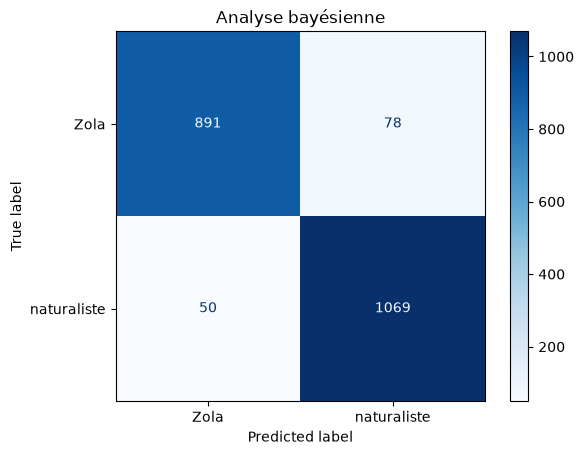

In [7]:
modele_bayes = MultinomialNB(alpha=1, fit_prior=False)

modele_bayes.fit(X_train_tfidf, y_train)

predictions = modele_bayes.predict(X_test_tfidf)

print(classification_report(y_test, predictions))

cm_bayesien = confusion_matrix(y_test, predictions)
print(cm_bayesien)

ConfusionMatrixDisplay(
    confusion_matrix=cm_bayesien,
    display_labels=modele_bayes.classes_
).plot(cmap="Blues")

plt.title("Analyse bayésienne")
plt.show()

In [8]:
modele_bayes.predict_proba(X_test_tfidf)

array([[0.18432938, 0.81567062],
       [0.08394015, 0.91605985],
       [0.57288143, 0.42711857],
       ...,
       [0.33795378, 0.66204622],
       [0.55831459, 0.44168541],
       [0.73454855, 0.26545145]], shape=(2088, 2))

### 8.2 Régression logistique

=== Régression logistique ===
              precision    recall  f1-score   support

        Zola      0.984     0.961     0.972       969
 naturaliste      0.967     0.987     0.977      1119

    accuracy                          0.975      2088
   macro avg      0.975     0.974     0.974      2088
weighted avg      0.975     0.975     0.975      2088

Matrice de confusion :
[[ 931   38]
 [  15 1104]]


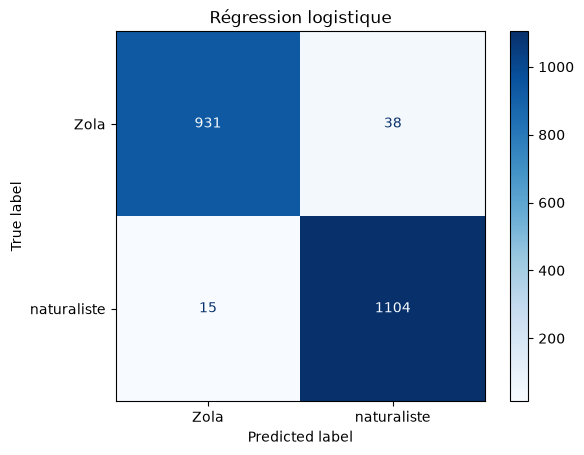

In [9]:
# Entraînement direct, sans Pipeline
modele_logistique = LogisticRegression(
    max_iter=3000,
    class_weight="balanced",
    solver="liblinear",
    random_state=42
)

modele_logistique.fit(X_train_tfidf, y_train)

predictions_logistiques = modele_logistique.predict(X_test_tfidf)

print("=== Régression logistique ===")
print(classification_report(y_test, predictions_logistiques, digits=3))

cm_logistique = confusion_matrix(y_test, predictions_logistiques)
print("Matrice de confusion :")
print(cm_logistique)

ConfusionMatrixDisplay(
    confusion_matrix=cm_logistique,
    display_labels=modele_logistique.classes_
).plot(cmap="Blues")

plt.title("Régression logistique")
plt.show()

In [10]:
modele_logistique.predict_proba(X_test_tfidf)

array([[0.11633235, 0.88366765],
       [0.07054029, 0.92945971],
       [0.40330516, 0.59669484],
       ...,
       [0.49903574, 0.50096426],
       [0.49107999, 0.50892001],
       [0.79169639, 0.20830361]], shape=(2088, 2))

In [11]:
print("Balanced accuracy :", balanced_accuracy_score(y_test,predictions_logistiques))

Balanced accuracy : 0.9736897439941123


### 8.3 Analyse discriminante linéaire après réduction SVD

L'analyse discriminante linéaire ne travaille pas directement sur une matrice TF-IDF creuse comportant plusieurs milliers de colonnes. On réduit donc d'abord la dimension avec `TruncatedSVD`, puis on standardise les composantes avant d'entraîner la LDA.

=== Analyse discriminante linéaire ===
Nombre de composantes SVD : 100
Variance expliquée cumulée par la SVD : 0.177
              precision    recall  f1-score   support

        Zola      0.977     0.976     0.977       969
 naturaliste      0.979     0.980     0.980      1119

    accuracy                          0.978      2088
   macro avg      0.978     0.978     0.978      2088
weighted avg      0.978     0.978     0.978      2088

Matrice de confusion :
[[ 946   23]
 [  22 1097]]


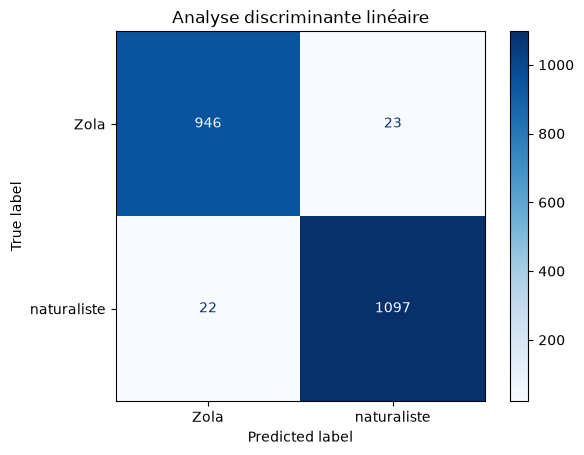

In [12]:
# Nombre de composantes compatible avec la taille réelle des données
n_composantes = min(
    100,
    X_train_tfidf.shape[0] - 1,
    X_train_tfidf.shape[1] - 1)

# Réduction de dimension
svd = TruncatedSVD(
    n_components=n_composantes,
    random_state=42)

X_train_svd = svd.fit_transform(X_train_tfidf)
X_test_svd = svd.transform(X_test_tfidf)

# Standardisation
scaler_lda = StandardScaler()
X_train_lda = scaler_lda.fit_transform(X_train_svd)
X_test_lda = scaler_lda.transform(X_test_svd)

# Analyse discriminante linéaire
modele_lda = LinearDiscriminantAnalysis(solver="svd")
modele_lda.fit(X_train_lda, y_train)

predictions_lda = modele_lda.predict(X_test_lda)

print("=== Analyse discriminante linéaire ===")
print(f"Nombre de composantes SVD : {n_composantes}")
print(
    "Variance expliquée cumulée par la SVD : "
    f"{svd.explained_variance_ratio_.sum():.3f}"
)
print(classification_report(y_test, predictions_lda, digits=3))

cm_lda = confusion_matrix(y_test, predictions_lda)
print("Matrice de confusion :")
print(cm_lda)

ConfusionMatrixDisplay(
    confusion_matrix=cm_lda,
    display_labels=modele_lda.classes_
).plot(cmap="Blues")

plt.title("Analyse discriminante linéaire")
plt.show()


## 9. Comparaison des performances sur le corpus de test

Les résultats du corpus de test sont présentés après la sélection du modèle
par validation croisée. Ils constituent une évaluation complémentaire.

In [13]:
comparaison_modeles = pd.DataFrame({
    "modèle": [
        "Analyse bayésienne",
        "Régression logistique",
        "Analyse discriminante linéaire"
    ],

    "accuracy": [
        accuracy_score(y_test, predictions),
        accuracy_score(y_test, predictions_logistiques),
        accuracy_score(y_test, predictions_lda)
    ],

    "f1_macro": [
        f1_score(y_test, predictions, average="macro"),
        f1_score(y_test, predictions_logistiques, average="macro"),
        f1_score(y_test, predictions_lda, average="macro")
    ]
})

print("\nComparaison des modèles sur le jeu de test :")

comparaison_modeles.sort_values(
    "f1_macro",
    ascending=False
).reset_index(drop=True)


Comparaison des modèles sur le jeu de test :


,modèle,accuracy,f1_macro
0,Analyse discriminante linéaire,0.978448,0.978335
1,Régression logistique,0.974617,0.974441
2,Analyse bayésienne,0.938697,0.938249


## 10. Évaluation finale au niveau des œuvres

Les probabilités des segments appartenant à une même œuvre sont moyennées
afin d'obtenir une prédiction unique par œuvre.

In [14]:
probabilites = modele_logistique.predict_proba(
    X_test_tfidf
)

classe_zola = list(
    modele_logistique.classes_
).index("Zola")

evaluation_oeuvres = df_test[
    ["source", "label"]
].copy()

evaluation_oeuvres["probabilite_zola"] = (
    probabilites[:, classe_zola]
)

resultats_oeuvres = (
    evaluation_oeuvres
    .groupby("source")
    .agg(
        label_reel=("label", "first"),
        probabilite_zola=(
            "probabilite_zola",
            "mean"
        )
    )
    .reset_index()
)

resultats_oeuvres["prediction"] = np.where(
    resultats_oeuvres["probabilite_zola"] >= 0.5,
    "Zola",
    "naturaliste"
)

print(
    classification_report(
        resultats_oeuvres["label_reel"],
        resultats_oeuvres["prediction"],
        digits=3
    )
)

resultats_oeuvres

              precision    recall  f1-score   support

        Zola      1.000     1.000     1.000         4
 naturaliste      1.000     1.000     1.000         9

    accuracy                          1.000        13
   macro avg      1.000     1.000     1.000        13
weighted avg      1.000     1.000     1.000        13



,source,label_reel,probabilite_zola,prediction
0,Edmond_de_Goncourt_La_Faustin.txt,naturaliste,0.155568,naturaliste
1,Guy_de_Maupassant_L_Âme_étrangère.txt,naturaliste,0.123327,naturaliste
2,Honoré_de_Balzac_Histoire_de_la_grandeur_et_de...,naturaliste,0.155588,naturaliste
3,J_H_Rosny_Nymphée.txt,naturaliste,0.138055,naturaliste
4,J_H_Rosny_aîné_Le_Jardin_de_Mary.txt,naturaliste,0.134083,naturaliste
5,Joris_Karl_Huysmans_En_ménage.txt,naturaliste,0.250422,naturaliste
6,Joris_Karl_Huysmans_En_route.txt,naturaliste,0.187294,naturaliste
7,Octave_Mirbeau_calvaire.txt,naturaliste,0.149975,naturaliste
8,Paul_de_Kock_Zizine.txt,naturaliste,0.071850,naturaliste
9,Émile_Zola_La_Conquête_de_Plassans.txt,Zola,0.781009,Zola


In [15]:
evaluation = df_test[["source", "label"]].copy()
evaluation["prediction"] = predictions_logistiques

performance_par_oeuvre = (
    evaluation
    .groupby("source")
    .apply(
        lambda groupe: pd.Series({
            "label_reel": groupe["label"].iloc[0],
            "n_segments": len(groupe),
            "accuracy_segments": (
                groupe["prediction"]
                == groupe["label"]
            ).mean(),
            "prediction_majoritaire": (
                groupe["prediction"]
                .value_counts()
                .idxmax()
            )
        }),
        include_groups=False
    )
    .reset_index()
)

print(performance_par_oeuvre)

print(
    "Accuracy moyenne par œuvre :",
    performance_par_oeuvre[
        "accuracy_segments"
    ].mean()
)

                                               source   label_reel  \
0                   Edmond_de_Goncourt_La_Faustin.txt  naturaliste   
1               Guy_de_Maupassant_L_Âme_étrangère.txt  naturaliste   
2   Honoré_de_Balzac_Histoire_de_la_grandeur_et_de...  naturaliste   
3                               J_H_Rosny_Nymphée.txt  naturaliste   
4                J_H_Rosny_aîné_Le_Jardin_de_Mary.txt  naturaliste   
5                   Joris_Karl_Huysmans_En_ménage.txt  naturaliste   
6                    Joris_Karl_Huysmans_En_route.txt  naturaliste   
7                         Octave_Mirbeau_calvaire.txt  naturaliste   
8                             Paul_de_Kock_Zizine.txt  naturaliste   
9              Émile_Zola_La_Conquête_de_Plassans.txt         Zola   
10                          Émile_Zola_La_Débâcle.txt         Zola   
11                             Émile_Zola_Le_Rêve.txt         Zola   
12        Émile_Zola_Son_Excellence_Eugène_Rougon.txt         Zola   

    n_segments  acc

## 11. Interprétation des modèles à partir du corpus d'entraînement

Cette section examine les paramètres appris par les modèles, sans tenir
compte de la fréquence des termes dans le corpus de test.

### 11.1 Termes caractéristiques selon Naive Bayes

In [16]:
classifieur = modele_bayes

mots = vectorizer.get_feature_names_out()
classes = classifieur.classes_

print("Ordre des classes :", classes)

# Différence des log-probabilités entre les deux classes
score_discriminant = (
    classifieur.feature_log_prob_[0]
    - classifieur.feature_log_prob_[1]
)

resultats_mots = pd.DataFrame({
    "mot": mots,
    f"score_{classes[0]}": score_discriminant
})

# Mots les plus caractéristiques de la première classe
mots_classe_0 = resultats_mots.sort_values(
    f"score_{classes[0]}",
    ascending=False
).head(30)

# Mots les plus caractéristiques de la deuxième classe
mots_classe_1 = resultats_mots.sort_values(
    f"score_{classes[0]}",
    ascending=True
).head(30)

print(f"\nMots les plus caractéristiques de {classes[0]} :")
for _, ligne in mots_classe_0.iterrows():
    print(f"{ligne['mot']:<25} {ligne[f'score_{classes[0]}']:.3f}")

print(f"\nMots les plus caractéristiques de {classes[1]} :")
for _, ligne in mots_classe_1.iterrows():
    print(f"{ligne['mot']:<25} {-ligne[f'score_{classes[0]}']:.3f}")

Ordre des classes : ['Zola' 'naturaliste']

Mots les plus caractéristiques de Zola :
nana                      3.921
saccard                   3.771
gervaise                  3.688
coupeau                   3.551
mouret                    3.409
étienne                   3.398
octave                    3.354
claude                    3.344
buteau                    3.343
denise                    3.336
florent                   3.280
rougon                    3.173
hélène                    3.142
renée                     3.084
lisa                      3.071
chanteau                  3.058
josserand                 3.013
silvère                   2.994
albine                    2.994
maxime                    2.966
lantier                   2.888
maheu                     2.851
plassans                  2.844
fouan                     2.824
roubaud                   2.796
sandoz                    2.782
lorilleux                 2.780
quenu                     2.776
fauchery           

### 11.2 Coefficients de la régression logistique

In [17]:
# Termes les plus discriminants de la régression logistique
termes_logistiques = vectorizer.get_feature_names_out()
classes_logistiques = modele_logistique.classes_

print("Ordre des classes :", classes_logistiques)

# En classification binaire :
# - coefficient positif  -> classe classes_[1]
# - coefficient négatif  -> classe classes_[0]
coefficients = modele_logistique.coef_[0]

importance_logistique = pd.DataFrame({
    "terme": termes_logistiques,
    "coefficient": coefficients
})

n = 30

termes_classe_0 = (
    importance_logistique
    .sort_values("coefficient", ascending=True)
    .head(n))

termes_classe_1 = (
    importance_logistique
    .sort_values("coefficient", ascending=False)
    .head(n))

print(f"\nTermes les plus associés à {classes_logistiques[0]} :")
for _, ligne in termes_classe_0.iterrows():
    print(f"{ligne['terme']:<30} {ligne['coefficient']:.4f}")

print(f"\nTermes les plus associés à {classes_logistiques[1]} :")
for _, ligne in termes_classe_1.iterrows():
    print(f"{ligne['terme']:<30} {ligne['coefficient']:.4f}")

Ordre des classes : ['Zola' 'naturaliste']

Termes les plus associés à Zola :
saccard                        -4.6409
ça                             -3.9249
lorsque                        -3.5132
nana                           -3.4942
claude                         -3.1693
elle                           -3.1581
hélène                         -3.0477
avait                          -2.9024
mouret                         -2.8136
rougon                         -2.8120
renée                          -2.6437
pauline                        -2.6106
lorsqu                         -2.4796
maxime                         -2.4478
florent                        -2.4251
gervaise                       -2.4066
qu elle                        -2.3125
plassans                       -2.2789
octave                         -2.2245
étienne                        -2.1557
tandis que                     -2.1417
denise                         -2.1065
un instant                     -2.0553
silvère                  

## 12. Analyse post-hoc du corpus de test

Cette section examine les termes effectivement présents dans le corpus de
test. Elle est uniquement interprétative et n'est pas utilisée pour
modifier le prétraitement, sélectionner le modèle ou régler ses
hyperparamètres.

### 12.1 Présence et poids TF-IDF des termes dans le test

In [18]:
# Utilisation du TF-IDF commun
classifieur = modele_bayes

# Vocabulaire appris sur le train
termes = vectorizer.get_feature_names_out()

# Ordre réel des classes
classes = classifieur.classes_

print("Ordre des classes :", classes)

# Nombre d'extraits du test contenant chaque terme
presence_test = np.asarray((X_test_tfidf > 0).sum(axis=0)).ravel()

# Somme des poids TF-IDF de chaque terme dans le test
poids_tfidf_test = np.asarray(X_test_tfidf.sum(axis=0)).ravel()

# Score discriminant appris par Naive Bayes
# score positif : classe 0
# score négatif : classe 1
score_discriminant = (
    classifieur.feature_log_prob_[0]
    - classifieur.feature_log_prob_[1]
)

resultats = pd.DataFrame({
    "terme": termes,
    "score_discriminant": score_discriminant,
    "nb_extraits_test": presence_test,
    "poids_tfidf_test": poids_tfidf_test
})

# On conserve uniquement les termes présents dans le test
resultats_test = resultats[
    resultats["nb_extraits_test"] > 0
].copy()

print(f"\nNombre de termes du vocabulaire présents dans le test : "
      f"{len(resultats_test)}")

Ordre des classes : ['Zola' 'naturaliste']

Nombre de termes du vocabulaire présents dans le test : 9745


### 12.2 Termes discriminants de Naive Bayes présents dans le test

In [19]:
n = 30

termes_classe_0 = (
    resultats_test
    .sort_values("score_discriminant", ascending=False)
    .head(n)
)

termes_classe_1 = (
    resultats_test
    .sort_values("score_discriminant", ascending=True)
    .head(n)
)

print(f"\nTermes présents dans le test les plus caractéristiques de {classes[0]} :")

for _, ligne in termes_classe_0.iterrows():
    print(
        f"{ligne['terme']:<25} "
        f"score={ligne['score_discriminant']:.3f}  "
        f"extraits={int(ligne['nb_extraits_test'])}"
    )

print(f"\nTermes présents dans le test les plus caractéristiques de {classes[1]} :")

for _, ligne in termes_classe_1.iterrows():
    print(
        f"{ligne['terme']:<25} "
        f"score={-ligne['score_discriminant']:.3f}  "
        f"extraits={int(ligne['nb_extraits_test'])}")


Termes présents dans le test les plus caractéristiques de Zola :
mouret                    score=3.409  extraits=155
étienne                   score=3.398  extraits=5
octave                    score=3.354  extraits=19
claude                    score=3.344  extraits=4
florent                   score=3.280  extraits=6
rougon                    score=3.173  extraits=275
hélène                    score=3.142  extraits=1
maxime                    score=2.966  extraits=3
plassans                  score=2.844  extraits=104
lazare                    score=2.719  extraits=4
macquart                  score=2.709  extraits=22
caroline                  score=2.674  extraits=1
pascal                    score=2.672  extraits=4
miette                    score=2.625  extraits=2
véronique                 score=2.479  extraits=4
clotilde                  score=2.334  extraits=2
christine                 score=2.326  extraits=5
berthe                    score=2.249  extraits=44
lise                     

### 12.3 Contribution lexicale globale dans le corpus de test

L'indicateur ci-dessous combine le caractère discriminant appris par
Naive Bayes avec le poids TF-IDF total du terme dans le corpus de test.

Il s'agit d'un indicateur descriptif global. Il ne représente pas une
explication locale exacte de chaque prédiction.

In [20]:
resultats_test["contribution_test"] = (
    resultats_test["score_discriminant"]
    * resultats_test["poids_tfidf_test"]
)

contributions_zola = (
    resultats_test
    .sort_values("contribution_test", ascending=False)
    .head(30)
)

contributions_naturalistes = (
    resultats_test
    .sort_values("contribution_test", ascending=True)
    .head(30)
)


print(contributions_zola[["terme", "contribution_test"]])
print(contributions_naturalistes[["terme", "contribution_test"]])

           terme  contribution_test
7828      rougon         147.315643
5971      mouret          71.695176
2769        elle          63.959897
5           abbé          48.842887
4490    juliette          39.213979
2893    empereur          30.090767
4408        jean          27.016216
563        avait          25.437184
6881    plassans          22.627108
5349     lorsque          22.526082
7315     qu elle          19.829385
5342      lorsqu          19.081217
9737          ça          18.798064
8739  tandis que          14.529263
8737      tandis          13.645817
4487       jules          13.561949
3351         eut          13.520295
9178  un instant          13.460703
3357      eut un          13.340607
6362       oncle          12.790323
767       berthe          12.427728
9155     un coup          12.203511
4231         ils          12.117037
2001  de nouveau          11.484428
2662         dut          11.418890
4098    il avait          11.368163
4133      il eut          11